# UdaciSense: Optimized Object Recognition

## Notebook 1: Baseline Performance

In this notebook, you'll establish the baseline performance of the computer vision model. This will serve as the reference point for your optimization efforts.

Remember, the CTO has set specific requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

### Step 1. Set up the environment

In [ ]:
!pip install tqdm

In [ ]:
!pip install -U matplotlib

In [ ]:
!pip install seaborn

In [ ]:
!pip install numpy==1.26.4 pandas

In [1]:
#!cp -pr ../utils .
!ls -l utils

total 136
-rw-r--r-- 1 ubuntu ubuntu   244 Aug 14  2025 __init__.py
drwxr-xr-x 2 ubuntu ubuntu  4096 Mar  7 02:15 __pycache__
-rw-r--r-- 1 ubuntu ubuntu 20152 Aug 14  2025 compression.py
-rw-r--r-- 1 ubuntu ubuntu 12809 Aug 14  2025 data_loader.py
-rw-r--r-- 1 ubuntu ubuntu 23534 Aug 14  2025 evaluation.py
-rw-r--r-- 1 ubuntu ubuntu 15218 Feb 28 07:46 model.py
-rw-r--r-- 1 ubuntu ubuntu 51998 Aug 14  2025 visualization.py


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Import libraries
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset

# Import custom modules
from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, print_model_summary, train_model
from utils.evaluation import calculate_confusion_matrix, evaluate_model_metrics
from utils.visualization import plot_confusion_matrix, plot_training_history, plot_weight_distribution

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
np.__version__

'1.26.4'

In [5]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

# Set device to cuda, if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Devices available: ['cpu', 'cuda:0 (NVIDIA A10)']
Using device: cuda


In [6]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    # Basic seed setting
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Make cudnn deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For some PyTorch operations
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    # For DataLoader workers
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

In [7]:
# Create directories
model_type = "baseline_mobilenet"
models_dir = f"../models/{model_type}"
models_ckp_dir = f"{models_dir}/checkpoints"
results_dir = f"../results/{model_type}"

os.makedirs(models_ckp_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

### Step 2. Load the dataset

Extracting household classes from CIFAR100 for train set...


100%|██████████| 169M/169M [00:04<00:00, 41.0MB/s] 


Saving the household subset as raw images at ../data/household_images/train.
Saved 5000 images to ../data/household_images/train
Extracting household classes from CIFAR100 for test set...
Saving the household subset as raw images at ../data/household_images/test.
Saved 1000 images to ../data/household_images/test
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


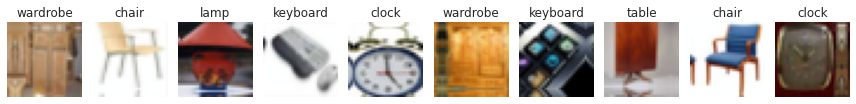


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


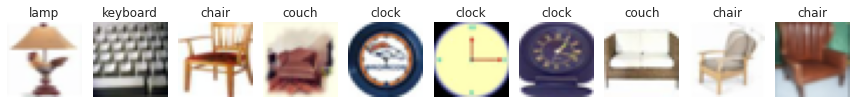

In [8]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Train the baseline model

In [9]:
# Initialize model
model = MobileNetV3_Household().to(device)
print_model_summary(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 317MB/s]

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

In [10]:
# Define training configuration
num_epochs = 50
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,  # Note that MobileNet is sensitive to high LRs
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.005,  # Peak learning rate
    steps_per_epoch=len(train_loader),
    epochs=num_epochs,
    pct_start=0.3,  # Spend 30% of training time warming up
    div_factor=25,  # Initial LR is max_lr/25
    final_div_factor=1000  # Final LR is max_lr/1000
)

training_config = {
    'num_epochs': num_epochs,
    'criterion': criterion,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'patience': 5,
    'device': device
}

In [11]:
# Train model given the training_config
training_stats, best_accuracy, best_epoch = train_model(
    model,
    train_loader,
    test_loader,
    training_config,
    checkpoint_path=f"{models_ckp_dir}/model.pth",
)

# Save training statistics
with open(f"{results_dir}/training_stats.json", 'w') as f:
    json.dump(training_stats, f, indent=4)

Total parameters: 1,528,106
Training with standard method for 50 epochs


Epoch 1/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 37.87it/s, loss=1.67, acc=65]  


Epoch 1/50 - Train Loss: 1.5945, Train Acc: 53.10%, Test Loss: 1.0423, Test Acc: 65.00%, LR: 0.000200, Time: 3.07s
New best model! Saving... (65.00%)
Model saved to ../models/baseline_mobilenet/checkpoints/model.pth


Epoch 2/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 45.81it/s, loss=1.21, acc=74.5] 


Epoch 2/50 - Train Loss: 0.7568, Train Acc: 74.12%, Test Loss: 0.7571, Test Acc: 74.50%, LR: 0.000200, Time: 2.39s
New best model! Saving... (74.50%)
Model saved to ../models/baseline_mobilenet/checkpoints/model.pth


...

Epoch 16/50 - Train Loss: 0.0650, Train Acc: 97.58%, Test Loss: 0.4395, Test Acc: 87.80%, LR: 0.000208, Time: 2.42s


Epoch 17/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 44.84it/s, loss=0.877, acc=86.6]


Epoch 17/50 - Train Loss: 0.0660, Train Acc: 97.64%, Test Loss: 0.5483, Test Acc: 86.60%, LR: 0.000210, Time: 2.41s


Epoch 18/50 [Test]: 100%|██████████| 8/8 [00:00<00:00, 44.86it/s, loss=0.84, acc=87.2] 


Epoch 18/50 - Train Loss: 0.0578, Train Acc: 97.98%, Test Loss: 0.5249, Test Acc: 87.20%, LR: 0.000211, Time: 2.41s
Early stopping at epoch 18. No improvement for 5 epochs.
Training completed. Best accuracy: 88.10%
Best model saved as '../models/baseline_mobilenet/checkpoints/model.pth' at epoch 13


In [12]:
model

MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (

### Step 4. Evaluate the baseline model

Evaluating model's performance on all metrics...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:00<00:00, 41.73it/s]


Baseline metrics saved at ../results/baseline_mobilenet/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:00<00:00, 43.91it/s]


Confusion matrix saved to ../results/baseline_mobilenet/confusion_matrix.png


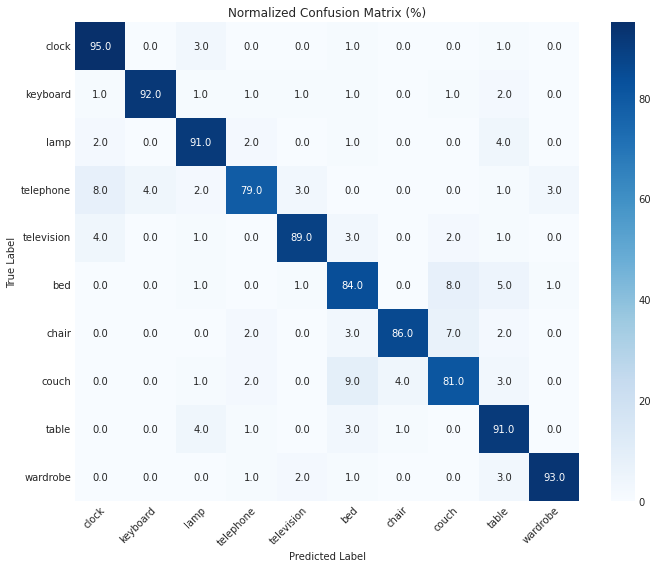

Training history plot saved to ../results/baseline_mobilenet/training_history.png


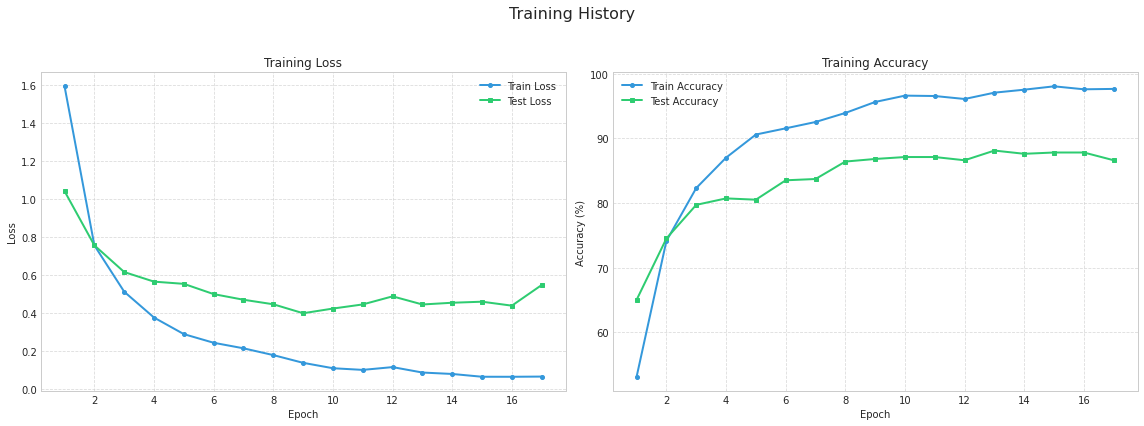

Weight distribution plot saved to ../results/baseline_mobilenet/weight_distribution.png


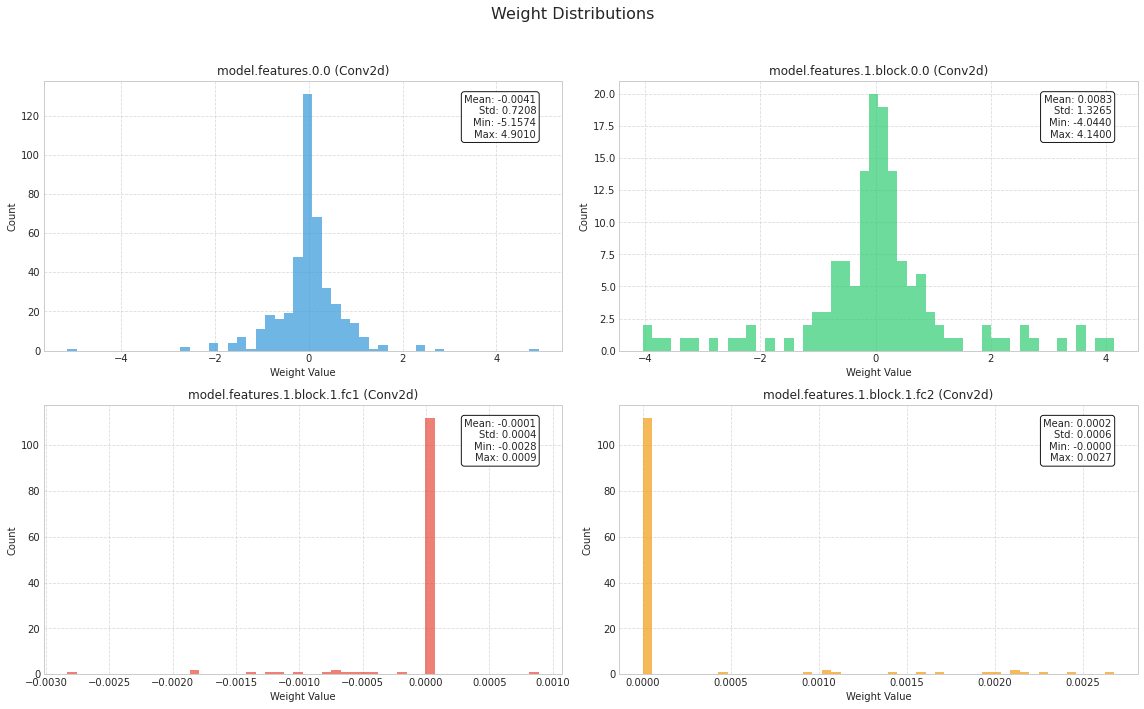

In [13]:
# Load the best model
model = load_model(f"{models_ckp_dir}/model.pth", device)

# Define evaluation input and output variables
class_names = test_loader.dataset.classes
n_classes = len(class_names)
input_size = get_input_size("CIFAR")

# Calculate and save model performance on all metrics
print("Evaluating model's performance on all metrics...")
baseline_metrics = evaluate_model_metrics(model, test_loader, device, n_classes, class_names, input_size, save_path=f"{results_dir}/metrics.json")

# Calculate, plot, and save confusion matrix
confusion_matrix = calculate_confusion_matrix(model, test_loader, device, n_classes)
_ = plot_confusion_matrix(confusion_matrix, class_names, f"{results_dir}/confusion_matrix.png")

# Plot and save training history
_ = plot_training_history(training_stats, f"{results_dir}/training_history.png")

# Plot weight distribution (can help guide optimization strategies)
_ = plot_weight_distribution(model, output_path=f"{results_dir}/weight_distribution.png")

### Step 5. Identify potential optimization approaches
Based on our baseline analysis, let's identify promising optimization approaches.

In [14]:
print(f"\nAll artifacts saved to:")
print(f" - Model: {models_ckp_dir}/model.pth")
print(f" - Metrics: {results_dir}/metrics.json")
print(f" - Confusion Matrix: {results_dir}/confusion_matrix.png")
print(f" - Training History: {results_dir}/training_history.png")
print(f" - Training Stats: {results_dir}/training_stats.json")
print(f" - Weight Distribution: {results_dir}/weight_distribution.png")


All artifacts saved to:
 - Model: ../models/baseline_mobilenet/checkpoints/model.pth
 - Metrics: ../results/baseline_mobilenet/metrics.json
 - Confusion Matrix: ../results/baseline_mobilenet/confusion_matrix.png
 - Training History: ../results/baseline_mobilenet/training_history.png
 - Training Stats: ../results/baseline_mobilenet/training_stats.json
 - Weight Distribution: ../results/baseline_mobilenet/weight_distribution.png


In [15]:
# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Optimization Targets:
Target Model Size: 5.96 --> 4.17 MB (30.0% reduction)
Target Inference Time (CPU): 447.70 --> 268.62 ms (40.0% reduction)
Target Inference Time (GPU): 3.28 --> 1.97 ms (40.0% reduction)
Minimum Acceptable Accuracy: 88.10 --> 83.69 (within 5.0% of baseline)


---------

**TODO: Analyze the baseline results and select appropriate compression techniques**

Now that you've established the baseline performance metrics for the UdaciSense object recognition model, complete an analysis that explores the optimization potential for this specific model architecture.

Consider these guiding questions:
- What is the baseline performance we need to optimize from?
- What characteristics of MobileNetV3 affect its optimization potential?
- Which compression techniques are most promising for this architecture and why?
- What trade-offs do you anticipate between size, speed, and accuracy?
- How might different techniques complement each other in a multi-stage approach?

Provide a well-reasoned analysis that includes recommendations for at least two specific compression techniques to implement in the next notebook.

# Optimization Analysis for UdaciSense Computer Vision Model

As can be seen from baseline results, we clearly need to bring down model size along with inference time while keeping accuracy within 5% of the baseline accuracy. Following are the requirement laid out:

**Optimization Targets**:

######################################################################

**Target Model Size**: 5.96 --> 4.17 MB (30.0% reduction)

**Target Inference Time (CPU)**: 447.70 --> 268.62 ms (40.0% reduction)

Target Inference Time (GPU): 3.28 --> 1.97 ms (40.0% reduction)

**Minimum Acceptable Accuracy**: 88.10 --> 83.69 (within 5.0% of baseline)
#######################################################################

Here GPU is not that important since the target device will not have GPU facility. We need to stress more on CPU inference timings. Further there are models like graph optimized model and quantized models which only run inference on CPU.

In order to reduce the size and inference time, we can optimize the MobileNetV3 model in three ways:
1) Reduce the sizing of components in backbone. However, this will require full retraining of model from scratch and we will lose out on transfer learning advantage from pretrained model. This might lead to missing accuracy targets.
2) Reduce the size of Linear layers in classification. This is a good potential target. We can keep pretrained weight and fine tune the model along with new resized classifier layers.
3) We can try combination of 1 and 2. However, we will lose out on gains inheriting from transfer learning and missing accuracy targets. We need to be mindful of the fact that majority of the model processing comes from backbone, unless we resize the components in backbone, we might miss out on achieving inference targets.
From above point, it is imperative that resizing classifier layers will not be sufficient, we will need to augment this with other optimizing techniques.

We can try out following techniques:
1) Dynamic Quantization --> This has the benefit of reducing the size of model (limited to only Linear layers as Conv2d is not supported with this type of quantization). Potential benefits : minimum setup requirements, easy implementation,  model size reduction, inference time reduction, minimum impact on accuracy as we are touching only Linear layers.
2) Static Quantization --> This has all the benefits of dynamic quantization plus support for quantizing Conv2d as well. Downside is that it requires quite a bit of set up plus calibration on sample dataset. This might reduce the model size by 1/4th of original and may potentially reduce inference timings. However, it will be interesting to see what impact it might have on accuracy as we are trimming down backbone and calibration step is not the same as fine tuning --> accuracy may take a hit. Potential benefits: model size reduction, inference time reduction. Downsides: Requires setup, may require careful execution of steps involved, chances of impact on accuracy.
3) Pruning: Model pruning is easy to implement except when implemented along with fine-tuning. It zeroes out the weights on insignificant model components and results in sparse model. This does not leads to reduction in model size or inference timings as the pruned weights still remain there and calculations still happen. Until and unless we remove pruned parts from model, this is highly likely not going to yield any benefits in my opinion. If we remove the pruned parts, we may need to check what impact it will have on overall model architecture and if remaining components can still work together lest it results in an unusable model. 
4) Quantization aware training: Requirements are more or less same as that of static quantization with benefits that model simulates quantization during training process itself and we can retrain the model. This has two benefits --> Model accuracy is least hit as model learns how to handle quantization intrinsically rather than forced upon it plus retraining helps model recover the lost accuracy so model is calibrated better. Benefits: model size reduction by 1/4, reduction in inference time, chances of keeping accuracy more or less same as that of original model.. Downside: Little cryptic to implement plus model loading during inference requires multiple steps to be executed as we will see during mobile format conversion phase.
5) Knowledge Distillation: We can reduce the model size and then further recover the lost accuracy from original model using KL Divergence as part of loss function. Touching upon the backbone has same drawbacks as mentioned earlier. Distillation has impact of enhancing the knowledge level of student model, however if the student model has to be trained from scratch(if we touch backbone) --> it might not yield desired benefit and even if it does, it might take long time to converge plus multi stage training. So, at the most we can reduce the classifier layer size coupled with distillation process. Benefits: model size reduction, maintains model accuracy, chances of reduced inference time. Downside : Requires setup and experimentation.
6) Graph Optimization: This is a cool technique which when used with other optimization techniques augments performance benefits. Benefits: Reduces model size by few fractions, reduction in inference time as it removes unnecessary compute nodes, keeps accuracy more or less same as that of model that is fed into it. 

From the discussion above and analysing benefits and downside potential, I think we should evaluate the following techniques for this project:
1) Dynamic Quantization
2) Quantization Aware Training
3) Knowledge Distillation
4) Graph Optimization

However, it seems that no single technique can yield the desired results alone. We can try out following combinations:
1) Dynamic Quantization plus graph optimization with latter further augmenting benefits provided by former.
2) QAT plus graph optimization --> same benefits as stated above.
3) Distillation plus dynamic quantization --> Dynamic quantization further reduces model size resulting in small model size, likely increase in inference time with minimum hit to accuracy
4) Distillation + Dyanamic Quantization + graph optimization: This combination further augments the results obtained by combo mentioned in point 3 above
5) Distillation plus graph optimization --> graph optimization augments the benefits from distillation with respect to model size, inference time and accuracy.


> 🚀 **Next Step:** 
> Experiment with the compression techniques you've chosen in notebook `02_compression.ipynb`  